# Phase 2 — Baseline Strategies & Backtesting Framework
## BTC Accumulation Strategy | Trilemma Foundation Capstone

**What this notebook builds:**
Before we can say our smart model is "better," we need to define
what "better than" means. That is what this notebook does.

We build four baseline strategies:
1. Dollar-Cost Averaging (DCA) — the primary benchmark
2. Lump Sum — buy everything on day one
3. Value Averaging — buy more when behind target, less when ahead
4. Momentum DCA — buy more during downtrends, less during uptrends

We then build a professional backtesting framework — a simulation
engine that runs any strategy against real historical price data
and measures exactly how it performed.

**Why this matters:**
The Trilemma capstone document states the goal is to build strategies
that "retain the key advantages of DCA while enhancing the efficiency
of Bitcoin acquisition." You cannot demonstrate enhancement without
first rigorously measuring DCA. This phase produces that measurement.

**Key concept — what does "better" mean for accumulation?**
Unlike traditional investing where we maximise returns, our goal is
to maximise the amount of BTC accumulated per dollar spent.
The primary metric is: satoshis per dollar (sats/USD).
A strategy that accumulates more BTC for the same budget is superior,
regardless of whether it "beat the market" in dollar terms.

## Setup: Load libraries and connect to Drive

We load the master dataset saved at the end of Phase 1.
This file already contains all price history, cycle labels,
and the computed features (volatility, SMA, Bollinger Bands).

If you get a file-not-found error:
→ Go back and run Phase1_EDA.ipynb first, then return here.

In [2]:
# ============================================================
# TITLE: Import libraries
# DESCRIPTION: All tools needed for Phase 2.
# New additions vs Phase 1:
# - dataclasses: lets us define clean Strategy configuration
#   objects (like a settings panel for each strategy)
# - typing: adds type hints so code is self-documenting
# - copy: lets us duplicate objects without modifying originals
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import os
import warnings
from dataclasses import dataclass, field
from typing import Optional
from datetime import datetime
import copy

warnings.filterwarnings("ignore")

print("Libraries imported.")
print(f"Run date: {datetime.today().strftime('%Y-%m-%d')}")

Libraries imported.
Run date: 2026-04-12


In [3]:
# ============================================================
# TITLE: Mount Google Drive and load the Phase 1 master dataset
# DESCRIPTION: We reload btc_eda_master.csv — the enriched
# dataset saved at the end of Phase 1. It contains price,
# cycle labels, volatility, SMA, Bollinger Bands, and drawdown.
# This is our single source of truth for all Phase 2 analysis.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = "/content/drive/MyDrive/BTC_Accumulation_Project"
RAW_DIR   = os.path.join(BASE_DIR, "data", "raw")
OUT_DIR   = os.path.join(BASE_DIR, "data", "processed")
CHART_DIR = os.path.join(BASE_DIR, "charts", "phase2_strategies")

os.makedirs(OUT_DIR,   exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

file_path = os.path.join(RAW_DIR, "btc_eda_master.csv")
df = pd.read_csv(file_path, parse_dates=["date"], index_col="date")

# Recompute any columns that may not have loaded cleanly
df["daily_return"]    = df["close"].pct_change()
df["log_return"]      = np.log(df["close"] / df["close"].shift(1))
df["sma_200"]         = df["close"].rolling(200).mean()
df["vol_30d"]         = df["daily_return"].rolling(30).std() * np.sqrt(365) * 100
df["sma_20"]          = df["close"].rolling(20).mean()
df["boll_std"]        = df["close"].rolling(20).std()
df["boll_upper"]      = df["sma_20"] + 2 * df["boll_std"]
df["boll_lower"]      = df["sma_20"] - 2 * df["boll_std"]
df["boll_pct_b"]      = ((df["close"] - df["boll_lower"]) /
                         (df["boll_upper"] - df["boll_lower"]))
df["pct_above_sma200"]= (df["close"] / df["sma_200"] - 1) * 100
rolling_max           = df["close"].cummax()
df["drawdown_pct"]    = (df["close"] - rolling_max) / rolling_max * 100

print("Dataset loaded successfully.")
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")
print(f"Total rows : {len(df):,} days")
print(f"Columns    : {len(df.columns)}")

Mounted at /content/drive
Dataset loaded successfully.
Date range : 2014-09-17 → 2026-04-11
Total rows : 4,225 days
Columns    : 22


## Step 1 — Define the Backtesting Simulation Engine

**What is a backtesting framework?**
A backtester is a simulation machine. You give it:
1. A strategy (a set of rules for when and how much to buy)
2. Historical price data
3. A budget and time period

It simulates what would have happened if you had applied
those rules in the past, day by day, using real prices.
The output is a complete record of every purchase, the
total BTC accumulated, and performance metrics.

**Why we build it as a reusable class:**
Instead of writing separate code for each strategy, we build
one backtesting engine that any strategy can plug into.
This is professional software design — it means adding a new
strategy in Phase 3 takes minutes, not hours.

**Our backtesting assumptions:**
1. We use the daily closing price as the purchase price.
   (In reality, large buyers use VWAP — we add slippage in Phase 4)
2. No transaction fees (we add this in Phase 4)
3. Fractional BTC purchases are allowed (realistic for institutions)
4. Budget is fixed per period — we cannot spend more than allocated
5. All purchases are "long only" — we never sell
   (this is an accumulation strategy, not a trading strategy)

**The primary performance metric — satoshis per dollar:**
1 Bitcoin = 100,000,000 satoshis (sats)
Sats per dollar = (total BTC accumulated × 100,000,000) / total USD spent
Higher sats per dollar = more efficient accumulation.


In [4]:
# ============================================================
# TITLE: Define the BacktestResult data container
# DESCRIPTION: A dataclass is a clean way to store related data
# together. Think of it as a labelled box that holds all the
# results from one backtest run. We will create one of these
# for each strategy we test. Using a dataclass instead of a
# plain dictionary makes the code more readable and prevents
# typos in key names.
# ============================================================

@dataclass
class BacktestResult:
    """Stores the complete results of one backtest run."""

    strategy_name   : str
    start_date      : str
    end_date        : str
    total_usd_spent : float
    total_btc       : float
    total_sats      : float
    sats_per_dollar : float
    avg_cost_basis  : float       # average USD paid per BTC
    final_btc_value : float       # BTC × final price
    total_return_pct: float       # (final value / cost - 1) × 100
    max_drawdown_cost: float      # worst drawdown of cost basis
    num_purchases   : int
    purchases_df    : pd.DataFrame = field(default_factory=pd.DataFrame)

    def summary(self):
        print(f"\n{'='*55}")
        print(f"  STRATEGY: {self.strategy_name}")
        print(f"{'='*55}")
        print(f"  Period          : {self.start_date} → {self.end_date}")
        print(f"  Total USD spent : ${self.total_usd_spent:>12,.2f}")
        print(f"  Total BTC       : {self.total_btc:>15.6f} BTC")
        print(f"  Total sats      : {self.total_sats:>15,.0f}")
        print(f"  Sats per dollar : {self.sats_per_dollar:>15,.2f}")
        print(f"  Avg cost basis  : ${self.avg_cost_basis:>12,.2f} per BTC")
        print(f"  Final BTC value : ${self.final_btc_value:>12,.2f}")
        print(f"  Total return    : {self.total_return_pct:>+12.1f}%")
        print(f"  Max cost drawdown: {self.max_drawdown_cost:>11.1f}%")
        print(f"  Number of buys  : {self.num_purchases:>15,}")

print("BacktestResult class defined.")

BacktestResult class defined.


In [5]:
# ============================================================
# TITLE: Build the core backtesting engine
# DESCRIPTION: This function is the heart of Phase 2.
# It takes a schedule — a DataFrame with columns (date, usd_amount)
# telling it "on this date, spend this many dollars" — and runs
# the simulation against real historical prices.
#
# How it works step by step:
# 1. For each row in the schedule, look up the closing price on that date
# 2. Calculate how much BTC that dollar amount buys at that price
# 3. Accumulate a running total of BTC and USD spent
# 4. Calculate all performance metrics at the end
#
# The function returns a BacktestResult object containing
# everything: every purchase, every metric, ready for comparison.
# ============================================================

def run_backtest(
    price_df      : pd.DataFrame,
    schedule      : pd.DataFrame,
    strategy_name : str
) -> BacktestResult:
    """
    Run a backtest given a price DataFrame and a purchase schedule.

    Parameters:
    -----------
    price_df      : DataFrame with DatetimeIndex and 'close' column
    schedule      : DataFrame with 'date' and 'usd_amount' columns
    strategy_name : Name label for this strategy

    Returns:
    --------
    BacktestResult object with all metrics and purchase history
    """

    purchases = []
    total_btc  = 0.0
    total_usd  = 0.0

    for _, row in schedule.iterrows():
        date       = pd.Timestamp(row["date"])
        usd_amount = row["usd_amount"]

        if usd_amount <= 0:
            continue

        # Find the closing price on this date
        # If the exact date is missing (weekend/holiday), use nearest available
        try:
            price = price_df.loc[date, "close"]
        except KeyError:
            # Look within a 3-day window
            window = price_df.loc[date : date + pd.Timedelta(days=3)]
            if len(window) == 0:
                continue
            price = window["close"].iloc[0]
            date  = window.index[0]

        if pd.isna(price) or price <= 0:
            continue

        btc_bought = usd_amount / price
        total_btc += btc_bought
        total_usd += usd_amount

        purchases.append({
            "date"       : date,
            "usd_spent"  : usd_amount,
            "price_paid" : price,
            "btc_bought" : btc_bought,
            "total_btc"  : total_btc,
            "total_usd"  : total_usd,
            "cost_basis" : total_usd / total_btc if total_btc > 0 else 0,
        })

    if len(purchases) == 0:
        raise ValueError(f"No valid purchases for strategy: {strategy_name}")

    purchases_df = pd.DataFrame(purchases).set_index("date")

    # ── Performance metrics ───────────────────────────────────
    final_price     = price_df["close"].iloc[-1]
    total_sats      = total_btc * 100_000_000
    sats_per_dollar = total_sats / total_usd if total_usd > 0 else 0
    avg_cost_basis  = total_usd / total_btc if total_btc > 0 else 0
    final_value     = total_btc * final_price
    total_return    = (final_value / total_usd - 1) * 100 if total_usd > 0 else 0

    # Maximum drawdown of cost basis
    # (how much did avg cost exceed contemporaneous market price?)
    merged = purchases_df[["cost_basis"]].copy()
    merged["market_price"] = price_df["close"].reindex(
        merged.index, method="nearest")
    merged["cost_vs_market"] = (merged["cost_basis"] /
                                 merged["market_price"] - 1) * 100
    max_dd_cost = merged["cost_vs_market"].max()

    return BacktestResult(
        strategy_name    = strategy_name,
        start_date       = str(purchases_df.index.min().date()),
        end_date         = str(purchases_df.index.max().date()),
        total_usd_spent  = total_usd,
        total_btc        = total_btc,
        total_sats       = total_sats,
        sats_per_dollar  = sats_per_dollar,
        avg_cost_basis   = avg_cost_basis,
        final_btc_value  = final_value,
        total_return_pct = total_return,
        max_drawdown_cost= max_dd_cost,
        num_purchases    = len(purchases_df),
        purchases_df     = purchases_df,
    )

print("Backtesting engine defined and ready.")

Backtesting engine defined and ready.


## Step 2 — Define the Backtest Period and Budget

**Choosing your backtest window:**
We test across two different windows:

- Window A — Full history (2015 to present):
Covers Cycles 1 through 4. Best for seeing long-term behaviour.
Starts in 2015 rather than 2010 because data quality and
liquidity before 2015 was very poor — results would be misleading.

- Window B — Recent two cycles (2020 to present):
Covers Cycles 3 and 4 only. Most relevant for institutional
investors today because market structure, liquidity, and
regulatory environment are far more comparable to present day.

**Budget assumption:**
We use $1,000 per month as the base budget.




In [6]:
# ============================================================
# TITLE: Define backtest configuration
# DESCRIPTION: All key settings in one place.
# Putting them here — rather than scattered through the code —
# means you only need to change one cell to re-run everything
# with different settings. This is called a "configuration block"
# and is standard practice in quantitative research.
# ============================================================

# ── Time windows ─────────────────────────────────────────────
WINDOW_A_START = "2015-01-01"   # Full history (3+ cycles)
WINDOW_A_END   = df.index.max().strftime("%Y-%m-%d")

WINDOW_B_START = "2020-05-11"   # Cycle 3 + 4 only
WINDOW_B_END   = df.index.max().strftime("%Y-%m-%d")

# ── Budget ───────────────────────────────────────────────────
MONTHLY_BUDGET = 1_000          # USD per month
DAILY_BUDGET   = MONTHLY_BUDGET / 30.44  # average days per month

# ── Colour scheme (consistent with Phase 1) ──────────────────
STRATEGY_COLOURS = {
    "DCA (daily)"        : "#378ADD",
    "DCA (weekly)"       : "#85B7EB",
    "Lump sum"           : "#888780",
    "Value averaging"    : "#7F77DD",
    "Momentum DCA"       : "#1D9E75",
}

# ── Filter price data to our window ──────────────────────────
df_a = df.loc[WINDOW_A_START : WINDOW_A_END].copy()
df_b = df.loc[WINDOW_B_START : WINDOW_B_END].copy()

print("Backtest configuration set.")
print(f"\nWindow A: {WINDOW_A_START} → {WINDOW_A_END}  ({len(df_a):,} days)")
print(f"Window B: {WINDOW_B_START} → {WINDOW_B_END}  ({len(df_b):,} days)")
print(f"\nMonthly budget : ${MONTHLY_BUDGET:,}")
print(f"Daily budget   : ${DAILY_BUDGET:.2f}")

Backtest configuration set.

Window A: 2015-01-01 → 2026-04-11  (4,119 days)
Window B: 2020-05-11 → 2026-04-11  (2,162 days)

Monthly budget : $1,000
Daily budget   : $32.85


## Strategy 1 — Dollar-Cost Averaging (DCA)

**What is DCA?**
Dollar-Cost Averaging means buying a fixed dollar amount of Bitcoin
at regular intervals, regardless of price. If the price is high,
you buy less BTC. If the price is low, you buy more BTC.

**Why DCA is the right benchmark:** DCA is what most retail and institutional investors default to.
It requires no forecasting skill and is easy to execute.
If your advanced model cannot beat DCA, it has no value.
The Trilemma capstone document explicitly states:
"While Dollar-Cost Averaging remains a widely utilised approach,
it may prove suboptimal amid such competitive dynamics."

**Two variants of DCA:**
- Daily DCA: divide monthly budget by ~30 and buy every day
- Weekly DCA: divide monthly budget by ~4.3 and buy every Monday
Daily DCA is more granular and typically performs slightly better.
We test both as separate baselines.

In [7]:
# ============================================================
# TITLE: Strategy 1A — Daily DCA schedule generator
# DESCRIPTION: We generate a purchase schedule for daily DCA.
# A "schedule" is a simple DataFrame with two columns:
#   date       — the day to make a purchase
#   usd_amount — how many dollars to spend that day
# For DCA, every single trading day gets the same fixed amount.
# We divide the monthly budget by 30.44 (avg days/month) to get
# the daily amount — this ensures we spend exactly the right
# total over any given month.
# ============================================================

def make_dca_schedule(price_df, daily_amount, label="DCA (daily)"):
    """
    Generate a daily DCA purchase schedule.

    Every trading day in price_df gets the same fixed purchase amount.
    This is the simplest possible accumulation strategy —
    no forecasting, no timing, just consistent automated buying.
    """
    schedule = pd.DataFrame({
        "date"      : price_df.index,
        "usd_amount": daily_amount,
    })
    return schedule

def make_weekly_dca_schedule(price_df, monthly_budget, label="DCA (weekly)"):
    """
    Generate a weekly DCA schedule — buy every Monday.
    Weekly DCA is more practical for many investors and
    produces fewer transaction costs than daily.
    """
    weekly_amount = monthly_budget / 4.348   # avg Mondays per month
    mondays = price_df[price_df.index.dayofweek == 0]  # 0 = Monday
    schedule = pd.DataFrame({
        "date"      : mondays.index,
        "usd_amount": weekly_amount,
    })
    return schedule

# Generate schedules for both windows
schedule_dca_daily_a  = make_dca_schedule(df_a, DAILY_BUDGET)
schedule_dca_daily_b  = make_dca_schedule(df_b, DAILY_BUDGET)
schedule_dca_weekly_a = make_weekly_dca_schedule(df_a, MONTHLY_BUDGET)
schedule_dca_weekly_b = make_weekly_dca_schedule(df_b, MONTHLY_BUDGET)

print("DCA schedules generated.")
print(f"\nDaily DCA (Window A):")
print(f"  Purchase days : {len(schedule_dca_daily_a):,}")
print(f"  Per purchase  : ${DAILY_BUDGET:.2f}")
print(f"  Approx total  : ${len(schedule_dca_daily_a) * DAILY_BUDGET:,.0f}")

print(f"\nWeekly DCA (Window A):")
print(f"  Purchase days : {len(schedule_dca_weekly_a):,}")
print(f"  Per purchase  : ${MONTHLY_BUDGET/4.348:.2f}")

DCA schedules generated.

Daily DCA (Window A):
  Purchase days : 4,119
  Per purchase  : $32.85
  Approx total  : $135,315

Weekly DCA (Window A):
  Purchase days : 588
  Per purchase  : $229.99


In [8]:
# ============================================================
# TITLE: Run DCA backtests and display results
# DESCRIPTION: We pass our schedules into the backtest engine.
# The engine simulates every purchase, tracks running totals,
# and returns a BacktestResult with all performance metrics.
# We run both daily and weekly DCA on both time windows —
# giving us 4 DCA baselines to compare against later.
# ============================================================

# Run all four DCA backtests
result_dca_daily_a  = run_backtest(df_a, schedule_dca_daily_a,  "DCA (daily)")
result_dca_weekly_a = run_backtest(df_a, schedule_dca_weekly_a, "DCA (weekly)")
result_dca_daily_b  = run_backtest(df_b, schedule_dca_daily_b,  "DCA (daily)")
result_dca_weekly_b = run_backtest(df_b, schedule_dca_weekly_b, "DCA (weekly)")

print("DCA BACKTEST RESULTS — WINDOW A (2015 to present)")
result_dca_daily_a.summary()
result_dca_weekly_a.summary()

print("\n\nDCA BACKTEST RESULTS — WINDOW B (2020 to present)")
result_dca_daily_b.summary()
result_dca_weekly_b.summary()



DCA BACKTEST RESULTS — WINDOW A (2015 to present)

  STRATEGY: DCA (daily)
  Period          : 2015-01-01 → 2026-04-11
  Total USD spent : $  135,315.37
  Total BTC       :       80.440273 BTC
  Total sats      :   8,044,027,330
  Sats per dollar :       59,446.51
  Avg cost basis  : $    1,682.18 per BTC
  Final BTC value : $5,876,505.72
  Total return    :      +4242.8%
  Max cost drawdown:        50.1%
  Number of buys  :           4,119

  STRATEGY: DCA (weekly)
  Period          : 2015-01-05 → 2026-04-06
  Total USD spent : $  135,234.59
  Total BTC       :       80.005011 BTC
  Total sats      :   8,000,501,145
  Sats per dollar :       59,160.17
  Avg cost basis  : $    1,690.33 per BTC
  Final BTC value : $5,844,707.98
  Total return    :      +4221.9%
  Max cost drawdown:        18.5%
  Number of buys  :             588


DCA BACKTEST RESULTS — WINDOW B (2020 to present)

  STRATEGY: DCA (daily)
  Period          : 2020-05-11 → 2026-04-11
  Total USD spent : $   71,024.97
  To

## Strategy 2 — Lump Sum

**What is lump sum investing?**
Lump sum means investing the entire budget on day one —
rather than spreading it over time.

**When does lump sum beat DCA?**
Historically, in markets that trend upward over time, lump sum
investing beats DCA roughly 2/3 of the time (Vanguard, 2012).
The logic: every day you delay investing, you risk missing upside
in a rising market. DCA sacrifices expected return in exchange
for reduced timing risk.

**Why we test lump sum:**
It is the theoretical upper bound in a perfectly rising market.
If DCA beats lump sum in your backtest, it means Bitcoin's
volatility creates enough dip-buying opportunities that spreading
purchases out was actually beneficial.



In [9]:
# ============================================================
# TITLE: Strategy 2 — Lump Sum schedule generator
# DESCRIPTION: Lump sum spends the entire period's budget on
# the very first day. We calculate the total budget as:
# daily_amount × number of trading days in the period.
# This ensures a fair comparison — both DCA and Lump Sum
# spend the same total dollars, just at different times.
# This is called "budget-matched comparison" and is essential
# for fair strategy evaluation. Without it, a strategy that
# simply spends more money will always appear to win.
# ============================================================

def make_lump_sum_schedule(price_df, daily_amount):
    """
    Spend the entire period's budget on day one.
    Budget is matched to DCA: same total dollars, different timing.
    """
    total_budget = daily_amount * len(price_df)
    first_day    = price_df.index[0]

    schedule = pd.DataFrame({
        "date"      : [first_day],
        "usd_amount": [total_budget],
    })
    return schedule

# Generate lump sum schedules
schedule_ls_a = make_lump_sum_schedule(df_a, DAILY_BUDGET)
schedule_ls_b = make_lump_sum_schedule(df_b, DAILY_BUDGET)

# Run backtests
result_ls_a = run_backtest(df_a, schedule_ls_a, "Lump sum")
result_ls_b = run_backtest(df_b, schedule_ls_b, "Lump sum")

total_budget_a = DAILY_BUDGET * len(df_a)
total_budget_b = DAILY_BUDGET * len(df_b)

print(f"Lump sum invests ${total_budget_a:,.0f} on {df_a.index[0].date()} (Window A)")
print(f"Lump sum invests ${total_budget_b:,.0f} on {df_b.index[0].date()} (Window B)")

print("\nLUMP SUM RESULTS — Window A")
result_ls_a.summary()

print("\nLUMP SUM RESULTS — Window B")
result_ls_b.summary()

Lump sum invests $135,315 on 2015-01-01 (Window A)
Lump sum invests $71,025 on 2020-05-11 (Window B)

LUMP SUM RESULTS — Window A

  STRATEGY: Lump sum
  Period          : 2015-01-01 → 2015-01-01
  Total USD spent : $  135,315.37
  Total BTC       :      430.599230 BTC
  Total sats      :  43,059,923,041
  Sats per dollar :      318,219.00
  Avg cost basis  : $      314.25 per BTC
  Final BTC value : $31,457,113.92
  Total return    :     +23147.3%
  Max cost drawdown:         0.0%
  Number of buys  :               1

LUMP SUM RESULTS — Window B

  STRATEGY: Lump sum
  Period          : 2020-05-11 → 2020-05-11
  Total USD spent : $   71,024.97
  Total BTC       :        8.256993 BTC
  Total sats      :     825,699,284
  Sats per dollar :       11,625.48
  Avg cost basis  : $    8,601.80 per BTC
  Final BTC value : $  603,208.61
  Total return    :       +749.3%
  Max cost drawdown:         0.0%
  Number of buys  :               1


## Strategy 3 — Value Averaging (VA)

**What is Value Averaging?**
Value Averaging was developed by Michael Edleson (1991) and is
a more sophisticated cousin of DCA. Instead of investing a fixed
dollar amount each period, you invest whatever amount is needed
to reach a pre-set portfolio value target.

**How it works — a simple example:**

The key insight: VA automatically makes you buy MORE when prices
have fallen (portfolio below target) and LESS when prices have
risen (portfolio above target). This is a built-in contrarian signal.

**Why Value Averaging is relevant to the project:**
The Trilemma capstone asks for strategies that "retain the key
advantages of DCA while enhancing the efficiency of Bitcoin
acquisition." Value Averaging is the natural next step from DCA.
It adds one layer of intelligence — portfolio tracking — without
requiring any price prediction.

**Our implementation rule:**
We use a long-only constraint: we never sell Bitcoin.
If the portfolio is so far above target that VA would suggest selling,
we simply make a minimum purchase of $1 instead.
This is appropriate for an accumulation-only strategy.

In [10]:
# ============================================================
# TITLE: Strategy 3 — Value Averaging schedule generator
# DESCRIPTION: VA calculates how much to invest each period
# based on the gap between actual portfolio value and a
# pre-set growing target value.
#
# The target grows by a fixed amount each period (growth_per_period).
# On each purchase date:
#   target_value = period_number × growth_per_period
#   current_value = total_btc_held × current_price
#   amount_to_invest = target_value - current_value
#
# If amount_to_invest < 0 (portfolio above target), we use
# min_purchase to stay long-only (never sell).
# If amount_to_invest > max_purchase, we cap it to prevent
# runaway spending in extreme crashes.
# ============================================================

def make_value_averaging_schedule(
    price_df,
    growth_per_month = 1_000,    # how much the portfolio target grows monthly
    frequency        = "ME",     # "ME" = month-end, "W-MON" = weekly
    min_purchase     = 1.0,      # minimum spend (never sell)
    max_purchase     = 5_000,    # cap to avoid blowing budget in crashes
):
    """
    Generate a Value Averaging purchase schedule.

    VA targets a portfolio value that grows by a fixed amount each period.
    It automatically buys more when prices fall and less when prices rise.
    """

    # Resample to get period-end dates
    period_dates = price_df.resample(frequency).last().dropna()

    total_btc        = 0.0
    total_usd        = 0.0
    purchases        = []
    period_num       = 0

    # Scale growth_per_month to the resampling frequency
    if frequency == "ME":
        growth_per_period = growth_per_month
    elif frequency.startswith("W"):
        growth_per_period = growth_per_month / 4.348
    else:
        growth_per_period = growth_per_month / 30.44

    for date, row in period_dates.iterrows():
        period_num += 1
        price = row["close"]

        if pd.isna(price) or price <= 0:
            continue

        target_value  = period_num * growth_per_period
        current_value = total_btc  * price
        amount_needed = target_value - current_value

        # Apply long-only constraint and spending cap
        usd_to_invest = max(min_purchase, min(amount_needed, max_purchase))

        btc_bought  = usd_to_invest / price
        total_btc  += btc_bought
        total_usd  += usd_to_invest

        purchases.append({
            "date"          : date,
            "usd_amount"    : usd_to_invest,
            "target_value"  : target_value,
            "current_value" : current_value,
            "gap"           : amount_needed,
        })

    return pd.DataFrame(purchases)[["date", "usd_amount"]]

# Generate Value Averaging schedules
schedule_va_a = make_value_averaging_schedule(df_a, growth_per_month=MONTHLY_BUDGET)
schedule_va_b = make_value_averaging_schedule(df_b, growth_per_month=MONTHLY_BUDGET)

# Run backtests
result_va_a = run_backtest(df_a, schedule_va_a, "Value averaging")
result_va_b = run_backtest(df_b, schedule_va_b, "Value averaging")

print("Monthly spend distribution for Value Averaging (Window A):")
print(f"  Min monthly spend  : ${schedule_va_a['usd_amount'].min():>10,.2f}")
print(f"  Max monthly spend  : ${schedule_va_a['usd_amount'].max():>10,.2f}")
print(f"  Mean monthly spend : ${schedule_va_a['usd_amount'].mean():>10,.2f}")
print(f"  Total spend        : ${schedule_va_a['usd_amount'].sum():>10,.2f}")

print("\nVALUE AVERAGING RESULTS — Window A")
result_va_a.summary()

print("\nVALUE AVERAGING RESULTS — Window B")
result_va_b.summary()

Monthly spend distribution for Value Averaging (Window A):
  Min monthly spend  : $      1.00
  Max monthly spend  : $  1,767.17
  Mean monthly spend : $     59.97
  Total spend        : $  7,975.92

VALUE AVERAGING RESULTS — Window A

  STRATEGY: Value averaging
  Period          : 2015-04-30 → 2026-03-31
  Total USD spent : $    7,974.92
  Total BTC       :       29.558297 BTC
  Total sats      :   2,955,829,721
  Sats per dollar :      370,640.72
  Avg cost basis  : $      269.80 per BTC
  Final BTC value : $2,159,359.93
  Total return    :     +26976.9%
  Max cost drawdown:         5.2%
  Number of buys  :             132

VALUE AVERAGING RESULTS — Window B

  STRATEGY: Value averaging
  Period          : 2020-05-31 → 2026-03-31
  Total USD spent : $   38,055.22
  Total BTC       :        1.934590 BTC
  Total sats      :     193,458,989
  Sats per dollar :        5,083.64
  Avg cost basis  : $   19,670.95 per BTC
  Final BTC value : $  141,330.06
  Total return    :       +271.4%
 

## Strategy 4 — Momentum DCA

**What is Momentum DCA?**
Momentum DCA keeps the discipline of DCA (fixed schedule, fixed
total budget) but varies the purchase size based on a simple
price signal: how far is the price from its 200-day moving average?

The intuition is straightforward:
- When Bitcoin is 30% BELOW its 200-day SMA, it is in a
  bear market. History says this is a better time to accumulate.
  → Spend MORE than the daily baseline (up to 2× the base amount)

- When Bitcoin is 30% ABOVE its 200-day SMA, it is in a
  bull market rally. Accumulation is more expensive.
  → Spend LESS than the daily baseline (down to 0.5× the base)

- When Bitcoin is near the 200-day SMA, spend the baseline amount.

**The multiplier formula:**
We use a simple linear scaling:

  multiplier = 1.0 - (pct_above_sma200 / 60)
  clamped between 0.5 (min) and 2.0 (max)

This means:

  - At -30% below SMA → multiplier ≈ 1.5 (buy 50% more)
  - At 0% (at SMA)   → multiplier = 1.0 (normal DCA)
  - At +30% above SMA → multiplier ≈ 0.5 (buy 50% less)

**The budget constraint:**
Total spending is still matched to DCA — the multiplier is
normalised so that total dollars spent over the period equals
exactly what DCA would have spent. We are redistributing the
same total budget in a smarter way, not spending more overall.

**Why this strategy matters:**
This is the bridge between "dumb DCA" and "smart ML model."
It uses one signal (SMA regime) to improve over DCA.
In Phase 3 we will replace this single signal with a full ML
model using many signals simultaneously.


In [11]:
# ============================================================
# TITLE: Strategy 4 — Momentum DCA schedule generator
# DESCRIPTION: We scale each day's purchase amount based on
# how far the price sits below or above its 200-day SMA.
# The further below the SMA, the more we buy (contrarian).
# The further above, the less we buy (cautious).
#
# NORMALISATION — this is critical for fair comparison:
# After computing all raw multiplied amounts, we scale the
# entire schedule so the total matches DCA exactly.
# This ensures any performance difference is due to TIMING,
# not to spending more money overall.
# Without normalisation, a strategy that simply spends more
# would always look better — but that's not a fair test.
# ============================================================

def make_momentum_dca_schedule(
    price_df,
    daily_budget,
    sma_window   = 200,
    min_mult     = 0.5,    # minimum multiplier (never go below 50% of base)
    max_mult     = 2.0,    # maximum multiplier (never exceed 200% of base)
    scaling_denom= 60,     # controls how sensitive the multiplier is to SMA gap
):
    """
    Generate a Momentum DCA schedule.
    Buys more when price is below 200-day SMA, less when above.
    Total spend is normalised to match DCA exactly.
    """

    schedule_df = price_df[["close", "pct_above_sma200"]].copy()
    schedule_df = schedule_df.dropna(subset=["pct_above_sma200"])

    # ── Compute raw multiplier ────────────────────────────────
    # Positive pct_above_sma200 = price above SMA = reduce buying
    # Negative pct_above_sma200 = price below SMA = increase buying
    schedule_df["raw_mult"] = 1.0 - (
        schedule_df["pct_above_sma200"] / scaling_denom
    )
    schedule_df["multiplier"] = schedule_df["raw_mult"].clip(
        lower=min_mult, upper=max_mult
    )

    # ── Compute raw spend ─────────────────────────────────────
    schedule_df["raw_spend"] = daily_budget * schedule_df["multiplier"]

    # ── NORMALISE to match DCA total spend exactly ─────────────
    target_total   = daily_budget * len(price_df)
    current_total  = schedule_df["raw_spend"].sum()
    norm_factor    = target_total / current_total
    schedule_df["usd_amount"] = schedule_df["raw_spend"] * norm_factor

    schedule_df = schedule_df.reset_index().rename(columns={"date": "date"})

    return schedule_df[["date", "usd_amount", "multiplier"]]

# Generate schedules
schedule_mom_a = make_momentum_dca_schedule(df_a, DAILY_BUDGET)
schedule_mom_b = make_momentum_dca_schedule(df_b, DAILY_BUDGET)

# Run backtests (pass only date + usd_amount columns to engine)
result_mom_a = run_backtest(df_a, schedule_mom_a[["date","usd_amount"]], "Momentum DCA")
result_mom_b = run_backtest(df_b, schedule_mom_b[["date","usd_amount"]], "Momentum DCA")

# Show the multiplier distribution to verify it is working
print("Momentum DCA multiplier distribution (Window A):")
print(f"  Mean multiplier  : {schedule_mom_a['multiplier'].mean():.3f}")
print(f"  Min multiplier   : {schedule_mom_a['multiplier'].min():.3f}")
print(f"  Max multiplier   : {schedule_mom_a['multiplier'].max():.3f}")
print(f"  Days above 1.0x  : {(schedule_mom_a['multiplier'] > 1).sum():,}  (below SMA — buying more)")
print(f"  Days below 1.0x  : {(schedule_mom_a['multiplier'] < 1).sum():,}  (above SMA — buying less)")
print(f"  Total spend      : ${schedule_mom_a['usd_amount'].sum():,.0f}")
print(f"  DCA total spend  : ${DAILY_BUDGET * len(df_a):,.0f}")

print("\nMOMENTUM DCA RESULTS — Window A")
result_mom_a.summary()

print("\nMOMENTUM DCA RESULTS — Window B")
result_mom_b.summary()

Momentum DCA multiplier distribution (Window A):
  Mean multiplier  : 0.887
  Min multiplier   : 0.500
  Max multiplier   : 1.870
  Days above 1.0x  : 1,512  (below SMA — buying more)
  Days below 1.0x  : 2,514  (above SMA — buying less)
  Total spend      : $135,315
  DCA total spend  : $135,315

MOMENTUM DCA RESULTS — Window A

  STRATEGY: Momentum DCA
  Period          : 2015-04-04 → 2026-04-11
  Total USD spent : $  135,315.37
  Total BTC       :       67.571108 BTC
  Total sats      :   6,757,110,825
  Sats per dollar :       49,936.02
  Avg cost basis  : $    2,002.56 per BTC
  Final BTC value : $4,936,358.22
  Total return    :      +3548.0%
  Max cost drawdown:        15.7%
  Number of buys  :           4,026

MOMENTUM DCA RESULTS — Window B

  STRATEGY: Momentum DCA
  Period          : 2020-05-11 → 2026-04-11
  Total USD spent : $   71,024.97
  Total BTC       :        2.218076 BTC
  Total sats      :     221,807,578
  Sats per dollar :        3,122.95
  Avg cost basis  : $   

## Step 3 — Compare All Strategies

Now we put all four strategies side by side.

The most important column is: satoshis per dollar.
It answers the question: "for every dollar I spent, how many
satoshis did I end up with?" Higher = better accumulation.

Secondary metrics to compare:
- Average cost basis: did we buy cheap on average?
- Max cost drawdown: in the worst period, how expensive was our
  average cost relative to the current market price?
  (Low = good — we were never dramatically overpaying)
- Total return: what is the portfolio worth now vs what we spent?

In [12]:
# ============================================================
# TITLE: Side-by-side comparison table — all strategies
# DESCRIPTION: We collect results from every backtest run and
# display them in a single formatted table.
# We compute an "improvement vs DCA" column that shows
# percentage improvement in sats-per-dollar over the benchmark.
# ============================================================

def build_comparison_table(results_list, benchmark_name="DCA (daily)"):
    """Build a formatted comparison DataFrame from a list of BacktestResults."""

    rows = []
    for r in results_list:
        rows.append({
            "Strategy"         : r.strategy_name,
            "Total USD spent"  : f"${r.total_usd_spent:,.0f}",
            "Total BTC"        : f"{r.total_btc:.6f}",
            "Sats per dollar"  : f"{r.sats_per_dollar:,.2f}",
            "Avg cost basis"   : f"${r.avg_cost_basis:,.0f}",
            "Final value"      : f"${r.final_btc_value:,.0f}",
            "Total return"     : f"{r.total_return_pct:+.1f}%",
            "Max cost DD"      : f"{r.max_drawdown_cost:.1f}%",
            "N purchases"      : f"{r.num_purchases:,}",
        })

    table = pd.DataFrame(rows).set_index("Strategy")

    # Find the benchmark row for improvement calculation
    benchmark_sats = None
    for r in results_list:
        if r.strategy_name == benchmark_name:
            benchmark_sats = r.sats_per_dollar
            break

    if benchmark_sats:
        improvements = []
        for r in results_list:
            imp = (r.sats_per_dollar / benchmark_sats - 1) * 100
            improvements.append(f"{imp:+.2f}%")
        table["vs DCA (daily)"] = improvements

    return table

print("=" * 70)
print("  WINDOW A — Full history (2015 to present)")
print("=" * 70)
all_results_a = [
    result_dca_daily_a,
    result_dca_weekly_a,
    result_ls_a,
    result_va_a,
    result_mom_a,
]
table_a = build_comparison_table(all_results_a)
print(table_a.to_string())

print("\n\n" + "=" * 70)
print("  WINDOW B — Recent cycles (2020 to present)")
print("=" * 70)
all_results_b = [
    result_dca_daily_b,
    result_dca_weekly_b,
    result_ls_b,
    result_va_b,
    result_mom_b,
]
table_b = build_comparison_table(all_results_b)
print(table_b.to_string())


  WINDOW A — Full history (2015 to present)
                Total USD spent   Total BTC Sats per dollar Avg cost basis  Final value Total return Max cost DD N purchases vs DCA (daily)
Strategy                                                                                                                                   
DCA (daily)            $135,315   80.440273       59,446.51         $1,682   $5,876,506     +4242.8%       50.1%       4,119         +0.00%
DCA (weekly)           $135,235   80.005011       59,160.17         $1,690   $5,844,708     +4221.9%       18.5%         588         -0.48%
Lump sum               $135,315  430.599230      318,219.00           $314  $31,457,114    +23147.3%        0.0%           1       +435.30%
Value averaging          $7,975   29.558297      370,640.72           $270   $2,159,360    +26976.9%        5.2%         132       +523.49%
Momentum DCA           $135,315   67.571108       49,936.02         $2,003   $4,936,358     +3548.0%       15.7%    

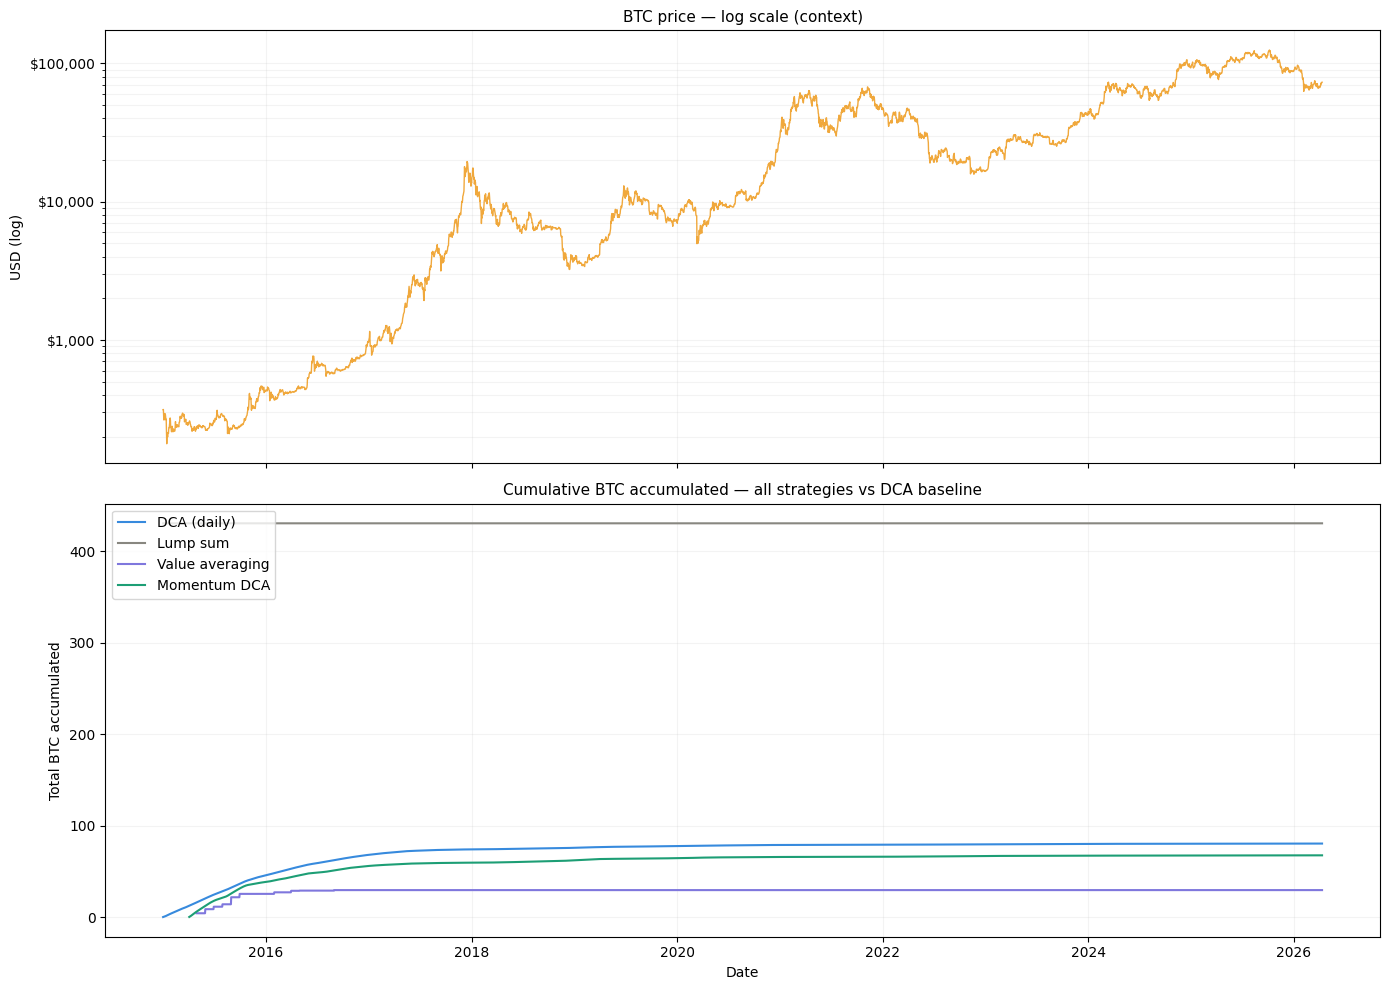

In [13]:
# ============================================================
# TITLE: Chart — BTC accumulated over time by strategy
# DESCRIPTION: We plot the running total of BTC accumulated
# for each strategy over the full backtest period.
# This chart makes the comparison visceral — you can see
# exactly when each strategy pulls ahead or falls behind.
# Periods where the gap widens = periods where the strategy's
# timing advantage (or disadvantage) was most pronounced.
# These periods should be mapped back to market events.
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

strategies_to_plot = {
    "DCA (daily)"    : (result_dca_daily_a,  "#378ADD"),
    "Lump sum"       : (result_ls_a,          "#888780"),
    "Value averaging": (result_va_a,           "#7F77DD"),
    "Momentum DCA"   : (result_mom_a,          "#1D9E75"),
}

# ── Top: price for context ────────────────────────────────────
axes[0].semilogy(df_a.index, df_a["close"],
                 color="#EF9F27", linewidth=1, alpha=0.9)
axes[0].set_title("BTC price — log scale (context)", fontsize=11)
axes[0].set_ylabel("USD (log)")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].grid(True, alpha=0.15, which="both")

# ── Bottom: cumulative BTC accumulated ───────────────────────
for strat_name, (result, colour) in strategies_to_plot.items():
    purch = result.purchases_df.copy()

    # Reindex to full date range and forward-fill BTC total
    full_idx = df_a.index
    purch_reindexed = purch["total_btc"].reindex(full_idx, method="ffill")

    axes[1].plot(purch_reindexed.index, purch_reindexed.values,
                 color=colour, linewidth=1.5, label=strat_name)

axes[1].set_title("Cumulative BTC accumulated — all strategies vs DCA baseline",
                  fontsize=11)
axes[1].set_ylabel("Total BTC accumulated")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=10, loc="upper left")
axes[1].grid(True, alpha=0.15)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "01_btc_accumulated_all_strategies.png"),
            dpi=150, bbox_inches="tight")
plt.show()

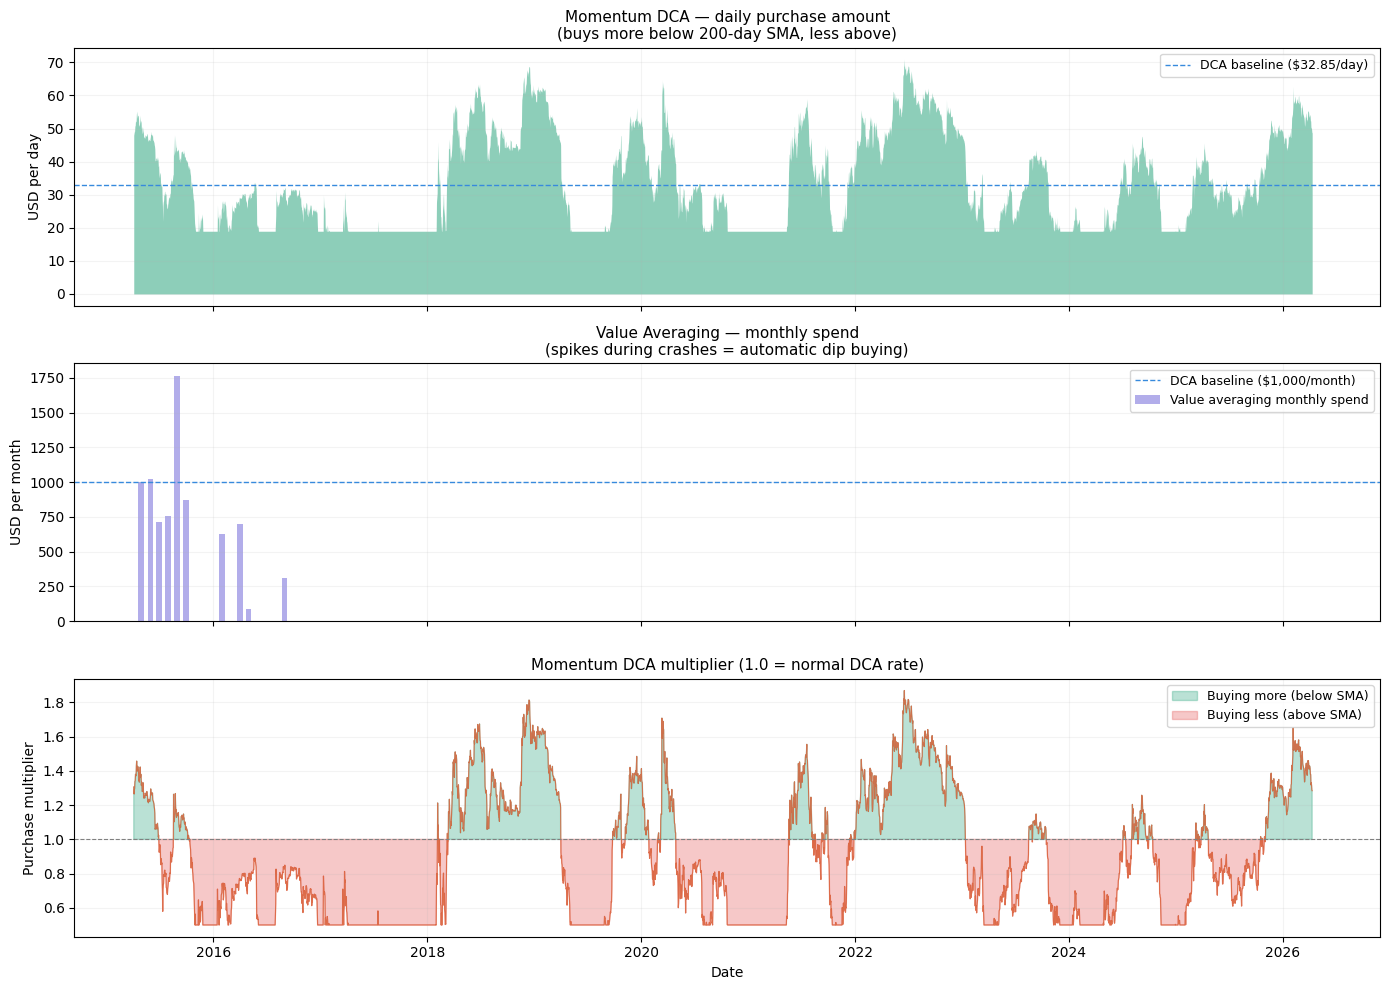

In [14]:
# ============================================================
# TITLE: Chart — Purchase amount variation by strategy
# DESCRIPTION: This chart shows the purchase schedule itself —
# how much was spent each day/week/month under each strategy.
# DCA shows a flat line (same every day — by design).
# Value Averaging shows high spikes during crashes (buying the dip)
# and near-zero amounts during bull runs.
# Momentum DCA shows a gradual variation tied to the SMA signal.
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# ── Momentum DCA daily spend ──────────────────────────────────
mom_spend = schedule_mom_a.set_index("date")["usd_amount"]
axes[0].fill_between(mom_spend.index, mom_spend.values,
                     color="#1D9E75", alpha=0.5, linewidth=0)
axes[0].axhline(DAILY_BUDGET, color="#378ADD", linewidth=1,
                linestyle="--", label=f"DCA baseline (${DAILY_BUDGET:.2f}/day)")
axes[0].set_title("Momentum DCA — daily purchase amount\n"
                  "(buys more below 200-day SMA, less above)", fontsize=11)
axes[0].set_ylabel("USD per day")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.15)

# ── Value Averaging monthly spend ─────────────────────────────
va_spend = schedule_va_a.set_index("date")["usd_amount"]
axes[1].bar(va_spend.index, va_spend.values,
            color="#7F77DD", alpha=0.6, width=20,
            label="Value averaging monthly spend")
axes[1].axhline(MONTHLY_BUDGET, color="#378ADD", linewidth=1,
                linestyle="--", label=f"DCA baseline (${MONTHLY_BUDGET:,}/month)")
axes[1].set_title("Value Averaging — monthly spend\n"
                  "(spikes during crashes = automatic dip buying)", fontsize=11)
axes[1].set_ylabel("USD per month")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.15)

# ── Momentum DCA multiplier ───────────────────────────────────
mult = schedule_mom_a.set_index("date")["multiplier"]
axes[2].plot(mult.index, mult.values,
             color="#D85A30", linewidth=0.8, alpha=0.8)
axes[2].fill_between(mult.index, mult.values, 1.0,
                     where=mult.values > 1.0,
                     color="#1D9E75", alpha=0.3, label="Buying more (below SMA)")
axes[2].fill_between(mult.index, mult.values, 1.0,
                     where=mult.values < 1.0,
                     color="#E24B4A", alpha=0.3, label="Buying less (above SMA)")
axes[2].axhline(1.0, color="gray", linewidth=0.8, linestyle="--")
axes[2].set_title("Momentum DCA multiplier (1.0 = normal DCA rate)",
                  fontsize=11)
axes[2].set_ylabel("Purchase multiplier")
axes[2].set_xlabel("Date")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.15)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "02_purchase_schedules.png"),
            dpi=150, bbox_inches="tight")
plt.show()

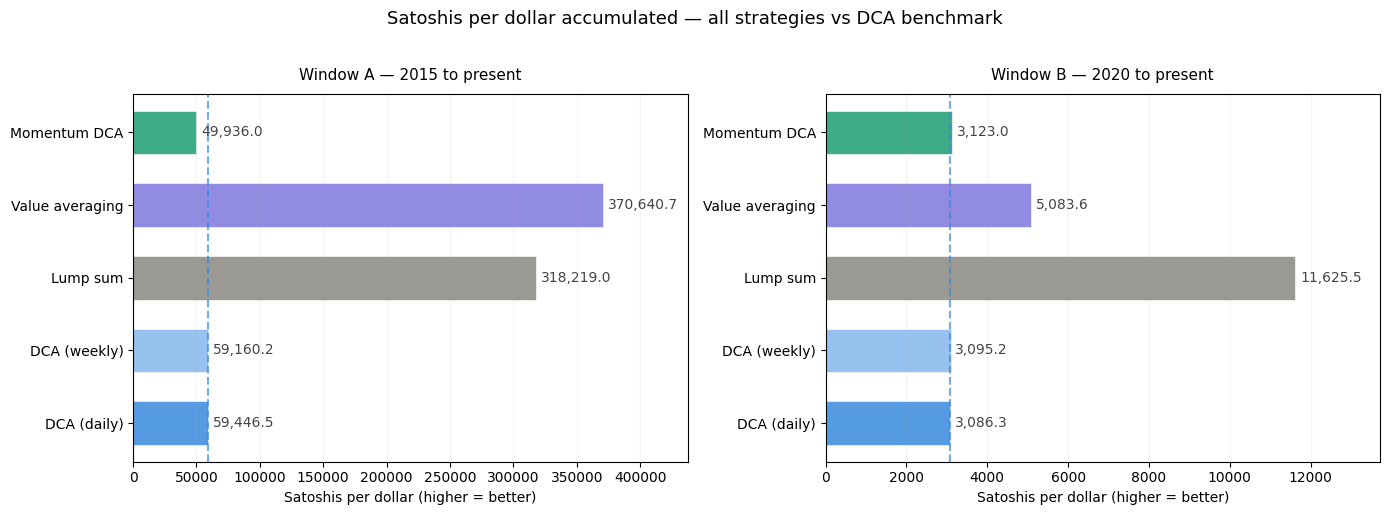

In [15]:
# ============================================================
# TITLE: Chart — Sats-per-dollar comparison bar chart
# DESCRIPTION: A simple bar chart comparing the headline metric
# across all strategies for both time windows.
# The DCA bar is highlighted in blue as the benchmark.
# All other bars are compared relative to it.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

windows = [
    ("Window A — 2015 to present", all_results_a, axes[0]),
    ("Window B — 2020 to present", all_results_b, axes[1]),
]

for title, results, ax in windows:
    names  = [r.strategy_name    for r in results]
    values = [r.sats_per_dollar  for r in results]
    colours = ["#378ADD" if "DCA (daily)" in n else
               "#85B7EB" if "weekly"      in n else
               "#888780" if "Lump"        in n else
               "#7F77DD" if "Value"       in n else
               "#1D9E75"
               for n in names]

    bars = ax.barh(names, values, color=colours, alpha=0.85,
                   edgecolor="white", linewidth=0.5, height=0.6)

    # Label each bar with its value
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + max(values) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,.1f}", va="center", fontsize=10,
                color="var(--color-text-primary)" if False else "#444")

    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("Satoshis per dollar (higher = better)")
    ax.grid(True, alpha=0.15, axis="x")
    ax.set_xlim(0, max(values) * 1.18)

    # Mark DCA line
    dca_val = next(r.sats_per_dollar for r in results
                   if r.strategy_name == "DCA (daily)")
    ax.axvline(dca_val, color="#378ADD", linewidth=1.5,
               linestyle="--", alpha=0.7)

plt.suptitle("Satoshis per dollar accumulated — all strategies vs DCA benchmark",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "03_sats_per_dollar_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# ============================================================
# TITLE: Save all results to Google Drive
# ============================================================

results_dir = os.path.join(BASE_DIR, "data", "results")
os.makedirs(results_dir, exist_ok=True)

# Save comparison tables
table_a.to_csv(os.path.join(results_dir, "comparison_window_a.csv"))
table_b.to_csv(os.path.join(results_dir, "comparison_window_b.csv"))
print("Comparison tables saved.")

# Save each strategy's purchase history
for result in all_results_a:
    safe_name = result.strategy_name.replace(" ", "_").replace("(","").replace(")","")
    path = os.path.join(results_dir, f"purchases_{safe_name}_windowA.csv")
    result.purchases_df.to_csv(path)
print("Purchase histories saved.")

# Save a plain-text thesis summary
summary_path = os.path.join(results_dir, "phase2_thesis_numbers.txt")
with open(summary_path, "w") as f:
    f.write("PHASE 2 BASELINE RESULTS — THESIS NUMBERS\n")
    f.write(f"Generated: {datetime.today().strftime('%Y-%m-%d')}\n\n")
    for result in all_results_a:
        f.write(f"\n{result.strategy_name} (Window A)\n")
        f.write(f"  Sats per dollar : {result.sats_per_dollar:,.2f}\n")
        f.write(f"  Total BTC       : {result.total_btc:.6f}\n")
        f.write(f"  Avg cost basis  : ${result.avg_cost_basis:,.0f}\n")
        f.write(f"  Total return    : {result.total_return_pct:+.1f}%\n")

print("\nAll Phase 2 outputs saved to Google Drive.")
print(f"Results folder: {results_dir}")

Comparison tables saved.
Purchase histories saved.

All Phase 2 outputs saved to Google Drive.
Results folder: /content/drive/MyDrive/BTC_Accumulation_Project/data/results


## Phase 2 complete — what we have built

**The backtesting framework** — a reusable engine that can run
any strategy against real BTC price data. Every strategy in
Phase 3 (ML models) will plug into this same engine.

**Four baseline strategies:**
1. DCA (daily)     — primary benchmark for all comparisons
2. DCA (weekly)    — practical variant, slightly fewer transactions
3. Lump sum        — theoretical upper bound in rising markets
4. Value averaging — automatic contrarian buying based on portfolio value
5. Momentum DCA    — signal-adjusted DCA using 200-day SMA

**Key outputs saved to Google Drive:**
- comparison_window_a.csv — full strategy comparison table
- comparison_window_b.csv — same for recent cycles
- purchases_[strategy]_windowA.csv — every individual purchase

**Next step → Phase 3: ML Models**
We replace the single SMA signal in Momentum DCA with a
machine learning model using all 7 features identified in Phase 1.